# CNN Image Classification — FashionMNIST
**Name:** Md. Ashadullah Al Galib
**Course:** AI/ML — CNN Assignment

This notebook:
1. Trains a CNN on the standard **FashionMNIST** dataset (10 classes, 28×28 grayscale).
2. Clones a GitHub repo containing 10 custom smartphone photos (one per class where possible).
3. Runs real-world prediction on those photos with confidence scores.
4. Produces training curves, a confusion matrix, a prediction gallery, and error analysis.

> **Before running:** replace `REPO_URL` and `STUDENT_ID` below with your own GitHub repo and ID.
> Click **Run All** — no manual uploads needed if `dataset/` in your repo has the 10 images.

In [1]:
# ============================================
# CONFIG — EDIT THESE TWO LINES ONLY
# ============================================
REPO_URL   = "https://github.com/galib603147-arch/CNN_Image_Classification.git"  # e.g. .../190110-cnn-assignment.git
STUDENT_ID = "220138"   # used to name the saved model file, e.g. 190110.pth


In [2]:
# ============================================
# 1. Imports
# ============================================
import os
import random
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, random_split
from torchvision import datasets, transforms

from sklearn.metrics import confusion_matrix
import seaborn as sns

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)


Using device: cuda


## 2. Clone custom dataset from GitHub
This pulls your `dataset/` folder (10 phone photos) automatically — no manual upload.

In [3]:
# ============================================
# 2. Clone repo (custom images) — automated, no manual upload
# ============================================
REPO_DIR = "https://github.com/galib603147-arch/CNN_Image_Classification/tree/main/dataset"

if not os.path.isdir(REPO_DIR):
    !git clone {REPO_URL} {REPO_DIR}
else:
    print("Repo already cloned.")

CUSTOM_IMG_DIR = os.path.join(REPO_DIR, "dataset")
print("Custom images found:")
for f in sorted(os.listdir(CUSTOM_IMG_DIR)):
    print(" -", f)


Cloning into 'https://github.com/galib603147-arch/CNN_Image_Classification/tree/main/dataset'...
remote: Enumerating objects: 21, done.
remote: Counting objects: 100% (21/21), done.
remote: Compressing objects: 100% (17/17), done.
remote: Total 21 (delta 0), reused 0 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (21/21), 6.49 MiB | 13.00 MiB/s, done.
Custom images found:
 - 01_sandal.jpg
 - 02_trouser.jpeg
 - 03_T-shirt.jpg
 - 04_dress.jpg
 - 05_Bag.jpeg
 - 06_Coat.png
 - 07_shirt.jpg
 - 08_sneaker.jpg
 - 09_pullover.jpg
 - 10_ankleboot.jpeg


## 3. Data Preprocessing
FashionMNIST is grayscale, 28×28. Same transform pipeline is reused later for the phone photos
(Resize → Grayscale → ToTensor → Normalize) so training and real-world inference match exactly.

In [4]:
# ============================================
# 3. Transforms
# ============================================
FMNIST_MEAN, FMNIST_STD = (0.2860,), (0.3530,)   # standard FashionMNIST stats

train_transform = transforms.Compose([
    transforms.RandomHorizontalFlip(p=0.3),
    transforms.ToTensor(),
    transforms.Normalize(FMNIST_MEAN, FMNIST_STD),
])

eval_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(FMNIST_MEAN, FMNIST_STD),
])

# Same pipeline for phone photos: force grayscale + resize to 28x28 to match training data
custom_transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=1),
    transforms.Resize((28, 28)),
    transforms.ToTensor(),
    transforms.Normalize(FMNIST_MEAN, FMNIST_STD),
])

CLASS_NAMES = ["T-shirt/top", "Trouser", "Pullover", "Dress", "Coat",
               "Sandal", "Shirt", "Sneaker", "Bag", "Ankle boot"]


In [5]:
# ============================================
# 4. Load FashionMNIST + DataLoaders
# ============================================
full_train = datasets.FashionMNIST(root="data", train=True, download=True, transform=train_transform)
test_set   = datasets.FashionMNIST(root="data", train=False, download=True, transform=eval_transform)

# 90/10 train/validation split
val_size = int(0.1 * len(full_train))
train_size = len(full_train) - val_size
train_set, val_set = random_split(full_train, [train_size, val_size],
                                   generator=torch.Generator().manual_seed(SEED))
# validation should use eval_transform (no augmentation) — swap dataset reference
val_set.dataset = datasets.FashionMNIST(root="data", train=True, download=True, transform=eval_transform)

BATCH_SIZE = 64
train_loader = DataLoader(train_set, batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(val_set,   batch_size=BATCH_SIZE, shuffle=False)
test_loader  = DataLoader(test_set,  batch_size=BATCH_SIZE, shuffle=False)

print(f"Train: {len(train_set)} | Val: {len(val_set)} | Test: {len(test_set)}")


100%|██████████| 26.4M/26.4M [00:02<00:00, 13.0MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 205kB/s]
100%|██████████| 4.42M/4.42M [00:01<00:00, 3.79MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 8.84MB/s]

Train: 54000 | Val: 6000 | Test: 10000


## 5. CNN Architecture
Two conv blocks (Conv → ReLU → MaxPool) followed by fully connected layers.

In [6]:
# ============================================
# 5. CNN Model
# ============================================
class CNN(nn.Module):
    def __init__(self, num_classes=10):
        super(CNN, self).__init__()
        self.conv1 = nn.Conv2d(1, 32, kernel_size=3, padding=1)   # 28x28x32
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)  # 14x14x64
        self.relu = nn.ReLU()
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)         # halves spatial dims

        self.fc1 = nn.Linear(64 * 7 * 7, 128)
        self.dropout = nn.Dropout(0.3)
        self.fc2 = nn.Linear(128, num_classes)

    def forward(self, x):
        x = self.pool(self.relu(self.conv1(x)))   # -> 14x14x32
        x = self.pool(self.relu(self.conv2(x)))   # -> 7x7x64
        x = x.view(x.size(0), -1)
        x = self.relu(self.fc1(x))
        x = self.dropout(x)
        x = self.fc2(x)
        return x

model = CNN(num_classes=10).to(device)
print(model)


CNN(
  (conv1): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (relu): ReLU()
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (fc1): Linear(in_features=3136, out_features=128, bias=True)
  (dropout): Dropout(p=0.3, inplace=False)
  (fc2): Linear(in_features=128, out_features=10, bias=True)
)


## 6. Training Loop

In [7]:
# ============================================
# 6. Loss, Optimizer, Training Loop
# ============================================
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3)

EPOCHS = 10
history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}

def run_epoch(loader, train_mode):
    model.train() if train_mode else model.eval()
    total_loss, correct, total = 0.0, 0, 0
    context = torch.enable_grad() if train_mode else torch.no_grad()
    with context:
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            if train_mode:
                optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            if train_mode:
                loss.backward()
                optimizer.step()
            total_loss += loss.item() * images.size(0)
            correct += (outputs.argmax(1) == labels).sum().item()
            total += images.size(0)
    return total_loss / total, correct / total

for epoch in range(1, EPOCHS + 1):
    tr_loss, tr_acc = run_epoch(train_loader, train_mode=True)
    val_loss, val_acc = run_epoch(val_loader, train_mode=False)

    history["train_loss"].append(tr_loss)
    history["val_loss"].append(val_loss)
    history["train_acc"].append(tr_acc)
    history["val_acc"].append(val_acc)

    print(f"Epoch {epoch:2d}/{EPOCHS} | "
          f"Train Loss: {tr_loss:.4f} Acc: {tr_acc:.4f} | "
          f"Val Loss: {val_loss:.4f} Acc: {val_acc:.4f}")

# Save model state dict
MODEL_PATH = f"{STUDENT_ID}.pth"
torch.save(model.state_dict(), MODEL_PATH)
print(f"Saved model to {MODEL_PATH}  (upload this into your repo's model/ folder)")


Epoch  1/10 | Train Loss: 0.5008 Acc: 0.8188 | Val Loss: 0.3256 Acc: 0.8788
Epoch  2/10 | Train Loss: 0.3293 Acc: 0.8819 | Val Loss: 0.2816 Acc: 0.8968
Epoch  3/10 | Train Loss: 0.2813 Acc: 0.8974 | Val Loss: 0.2449 Acc: 0.9095
Epoch  4/10 | Train Loss: 0.2521 Acc: 0.9078 | Val Loss: 0.2416 Acc: 0.9102
Epoch  5/10 | Train Loss: 0.2308 Acc: 0.9159 | Val Loss: 0.2284 Acc: 0.9143
Epoch  6/10 | Train Loss: 0.2156 Acc: 0.9209 | Val Loss: 0.2159 Acc: 0.9240
Epoch  7/10 | Train Loss: 0.2012 Acc: 0.9266 | Val Loss: 0.2111 Acc: 0.9243
Epoch  8/10 | Train Loss: 0.1859 Acc: 0.9322 | Val Loss: 0.2142 Acc: 0.9223
Epoch  9/10 | Train Loss: 0.1753 Acc: 0.9352 | Val Loss: 0.2197 Acc: 0.9240
Epoch 10/10 | Train Loss: 0.1647 Acc: 0.9383 | Val Loss: 0.1961 Acc: 0.9293
Saved model to 220138.pth  (upload this into your repo's model/ folder)


## 7. Training History Plots

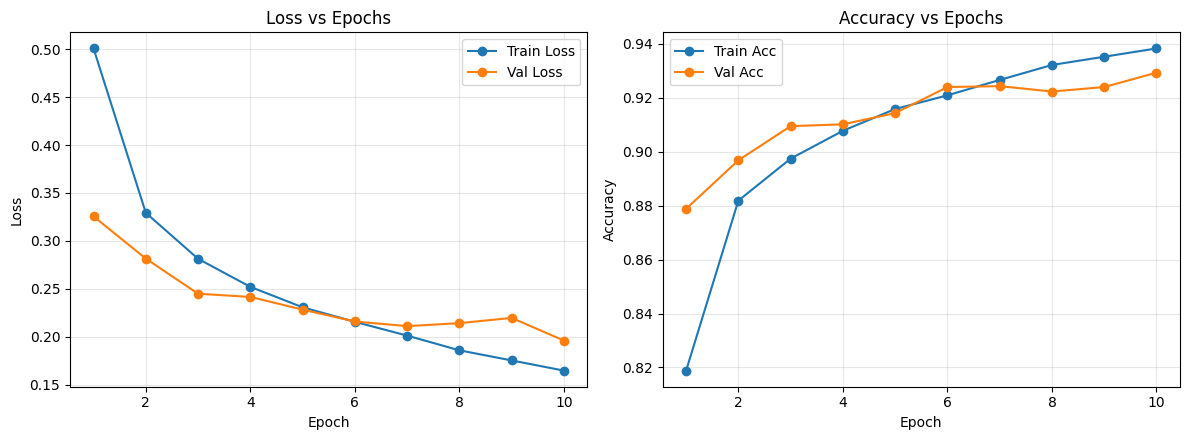

In [8]:
# ============================================
# 7. Loss & Accuracy curves
# ============================================
epochs_range = range(1, EPOCHS + 1)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

axes[0].plot(epochs_range, history["train_loss"], label="Train Loss", marker="o")
axes[0].plot(epochs_range, history["val_loss"], label="Val Loss", marker="o")
axes[0].set_title("Loss vs Epochs")
axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Loss")
axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(epochs_range, history["train_acc"], label="Train Acc", marker="o")
axes[1].plot(epochs_range, history["val_acc"], label="Val Acc", marker="o")
axes[1].set_title("Accuracy vs Epochs")
axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("Accuracy")
axes[1].legend(); axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig("training_curves.png", dpi=150)
plt.show()


## 8. Confusion Matrix (Standard Test Set)

Test Accuracy: 92.57%


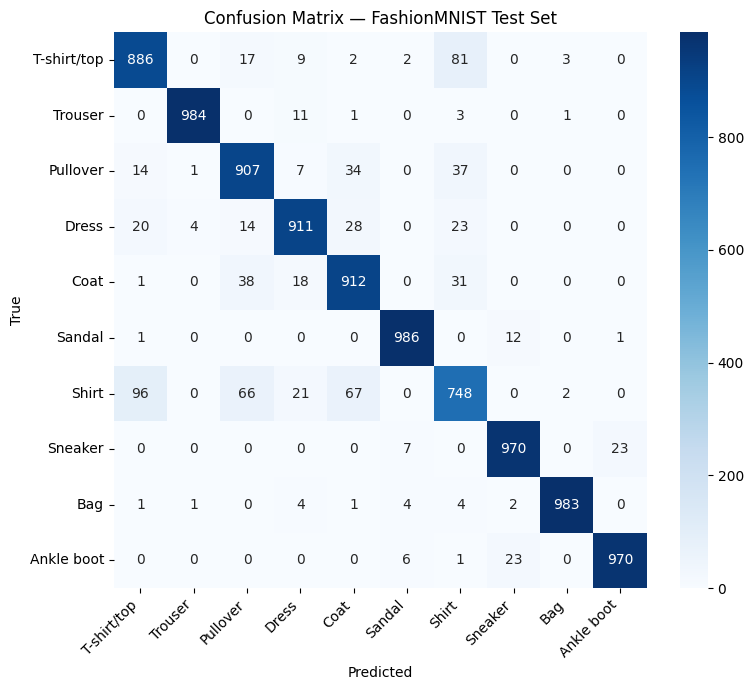

In [9]:
# ============================================
# 8. Confusion Matrix
# ============================================
model.eval()
all_preds, all_labels = [], []
with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        outputs = model(images)
        preds = outputs.argmax(1).cpu().numpy()
        all_preds.extend(preds)
        all_labels.extend(labels.numpy())

test_acc = (np.array(all_preds) == np.array(all_labels)).mean()
print(f"Test Accuracy: {test_acc*100:.2f}%")

cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(8, 7))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
plt.xlabel("Predicted"); plt.ylabel("True")
plt.title("Confusion Matrix — FashionMNIST Test Set")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig("confusion_matrix.png", dpi=150)
plt.show()


## 9. Real-World Prediction — Custom Phone Photos
Loads the 10 images cloned from your GitHub `dataset/` folder, applies the **exact same**
transform pipeline (Grayscale → Resize(28,28) → ToTensor → Normalize) used in training,
then predicts class + confidence for each.

In [10]:
# ============================================
# 9. Predict on custom smartphone photos
# ============================================
VALID_EXT = (".jpg", ".jpeg", ".png")
custom_files = sorted([f for f in os.listdir(CUSTOM_IMG_DIR) if f.lower().endswith(VALID_EXT)])
assert len(custom_files) > 0, "No images found in dataset/ — check your repo structure."

model.eval()
results = []  # (filename, PIL image, predicted label, confidence)

with torch.no_grad():
    for fname in custom_files:
        path = os.path.join(CUSTOM_IMG_DIR, fname)
        img = Image.open(path).convert("RGB")
        tensor = custom_transform(img).unsqueeze(0).to(device)  # (1,1,28,28)

        logits = model(tensor)
        probs = torch.softmax(logits, dim=1).squeeze(0)
        conf, pred_idx = torch.max(probs, dim=0)

        results.append((fname, img, CLASS_NAMES[pred_idx.item()], conf.item() * 100))

for fname, _, label, conf in results:
    print(f"{fname:20s} -> Pred: {label:12s} ({conf:.1f}%)")


01_sandal.jpg        -> Pred: Bag          (100.0%)
02_trouser.jpeg      -> Pred: Bag          (37.1%)
03_T-shirt.jpg       -> Pred: Bag          (100.0%)
04_dress.jpg         -> Pred: Bag          (100.0%)
05_Bag.jpeg          -> Pred: T-shirt/top  (97.7%)
06_Coat.png          -> Pred: Bag          (58.9%)
07_shirt.jpg         -> Pred: T-shirt/top  (43.7%)
08_sneaker.jpg       -> Pred: Bag          (100.0%)
09_pullover.jpg      -> Pred: Bag          (99.9%)
10_ankleboot.jpeg    -> Pred: Bag          (100.0%)


## 10. Custom Prediction Gallery

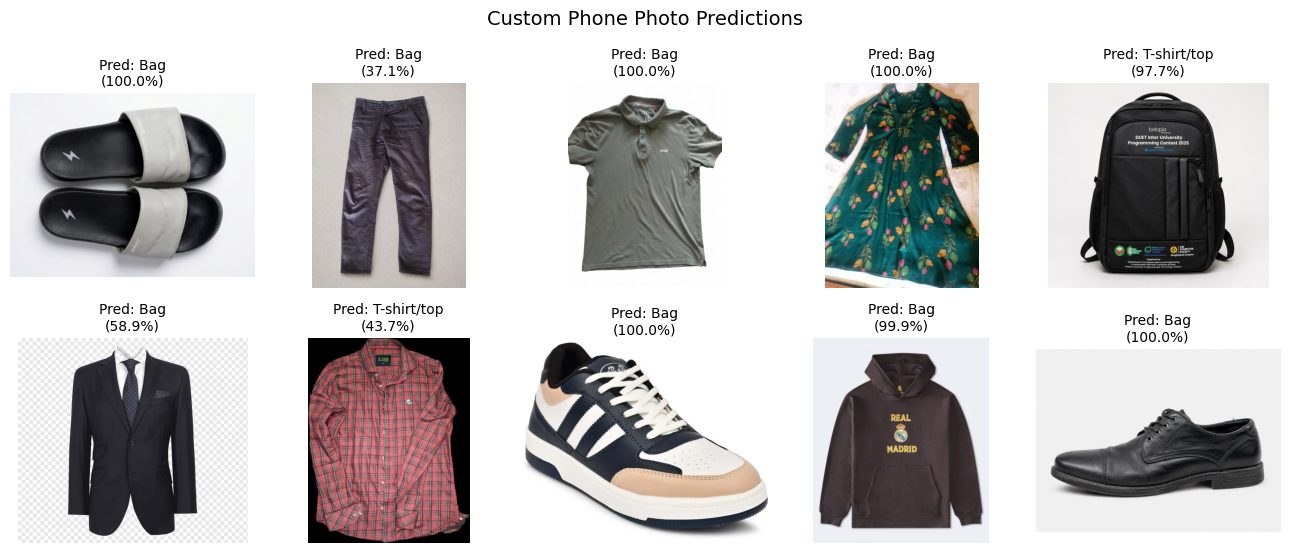

In [13]:
# ============================================
# 10. Gallery grid: image + "Pred: Class (conf%)"
# ============================================
n = len(results)
cols = 5
rows = (n + cols - 1) // cols

fig, axes = plt.subplots(rows, cols, figsize=(cols * 2.6, rows * 2.8))
axes = np.array(axes).reshape(-1)

for i, (fname, img, label, conf) in enumerate(results):
    axes[i].imshow(img)
    axes[i].set_title(f"Pred: {label}\n({conf:.1f}%)", fontsize=10)
    axes[i].axis("off")

for j in range(n, len(axes)):
    axes[j].axis("off")

plt.suptitle("Custom Phone Photo Predictions", fontsize=14)
plt.tight_layout()
plt.savefig("custom_prediction_gallery.png", dpi=150)
plt.show()


## 11. Visual Error Analysis
Three misclassified test-set images: True label vs Predicted label.

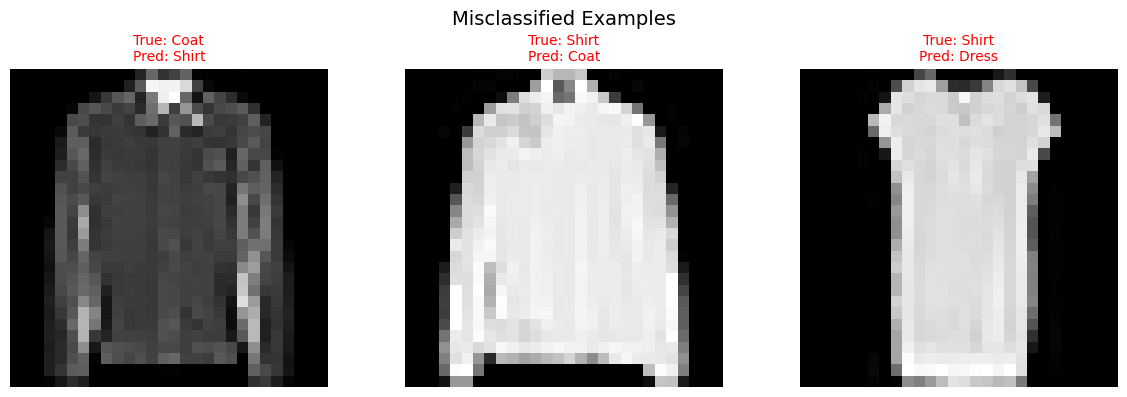

In [12]:
# ============================================
# 11. Error analysis — 3 random misclassified test images
# ============================================
all_preds_arr = np.array(all_preds)
all_labels_arr = np.array(all_labels)
wrong_idx = np.where(all_preds_arr != all_labels_arr)[0]

sample_wrong = np.random.choice(wrong_idx, size=min(3, len(wrong_idx)), replace=False)

fig, axes = plt.subplots(1, len(sample_wrong), figsize=(4 * len(sample_wrong), 4))
if len(sample_wrong) == 1:
    axes = [axes]

for ax, idx in zip(axes, sample_wrong):
    image_tensor, true_label = test_set[idx]
    img = image_tensor.squeeze(0).numpy() * FMNIST_STD[0] + FMNIST_MEAN[0]  # de-normalize
    pred_label = all_preds_arr[idx]

    ax.imshow(img, cmap="gray")
    ax.set_title(f"True: {CLASS_NAMES[true_label]}\nPred: {CLASS_NAMES[pred_label]}",
                 fontsize=10, color="red")
    ax.axis("off")

plt.suptitle("Misclassified Examples", fontsize=14)
plt.tight_layout()
plt.savefig("error_analysis.png", dpi=150)
plt.show()


## 12. Summary

| Metric | Value |
|---|---|
| Final Train Accuracy | printed above |
| Final Val Accuracy | printed above |
| Test Accuracy | printed above |
| Model file | `STUDENT_ID.pth` (upload to `model/` in repo) |

**Submission checklist**
- [ ] `dataset/` — 10 custom smartphone photos pushed to GitHub
- [ ] `model/STUDENT_ID.pth` — saved trained weights pushed to GitHub
- [ ] `STUDENT_ID.ipynb` — this notebook, pushed to GitHub
- [ ] `README.md` — architecture description + result plots
- [ ] Colab link + GitHub link submitted
- [ ] Verified "Run All" works top-to-bottom with a fresh runtime